# Multimodal Engagement Recognition ML Model
## Real-time Engagement Recognition in Children with Autism Spectrum Disorder

This pipeline builds a machine learning model using physiological signals (GSR, accelerometer, temperature) to classify engagement levels: Baseline (0), Low Engagement (1), and High Engagement (2).

In [7]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from scipy import signal
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings

warnings.filterwarnings('ignore')

print("✓ All imports successful")

✓ All imports successful


In [8]:
# Set up relative paths
BASE_PATH = Path("../data/Engagnition Dataset")
MODELS_PATH = Path("../models")
RESULTS_PATH = Path("../results")

# Create directories if they don't exist
MODELS_PATH.mkdir(exist_ok=True)
RESULTS_PATH.mkdir(exist_ok=True)

print(f"✓ Base path: {BASE_PATH}")
print(f"✓ Models path: {MODELS_PATH}")
print(f"✓ Results path: {RESULTS_PATH}")

✓ Base path: ../data/Engagnition Dataset
✓ Models path: ../models
✓ Results path: ../results


In [16]:
def load_participant_data(participant_path):
    """
    Load GSR, accelerometer, and temperature data for a participant.
    Returns a dictionary with DataFrames for each signal type.
    """
    data = {}
    
    try:
        # Load GSR data
        gsr_path = participant_path / "E4GsrData.csv"
        if gsr_path.exists():
            data['gsr'] = pd.read_csv(gsr_path)
        else:
            data['gsr'] = None
            
        # Load Accelerometer data
        acc_path = participant_path / "E4AccData.csv"
        if acc_path.exists():
            data['acc'] = pd.read_csv(acc_path)
        else:
            data['acc'] = None
            
        # Load Temperature data
        tmp_path = participant_path / "E4TmpData.csv"
        if tmp_path.exists():
            data['tmp'] = pd.read_csv(tmp_path)
        else:
            data['tmp'] = None
            
    except Exception as e:
        print(f"Error loading data from {participant_path}: {e}")
        return None
        
    return data if all(v is not None for v in data.values()) else None


def get_condition_label(condition_name):
    """
    Map condition name to label.
    Baseline: 0, LPE: 1, HPE: 2
    """
    mapping = {
        'Baseline condition': 0,
        'LPE condition': 1,
        'HPE condition': 2
    }
    return mapping.get(condition_name, -1)


def collect_all_data():
    """
    Traverse all participant folders and collect data.
    Returns list of tuples: (participant_id, condition, data_dict)
    """
    collected_data = []
    
    # Iterate through all conditions
    for condition_folder in sorted(BASE_PATH.iterdir()):
        if not condition_folder.is_dir():
            continue
            
        condition_name = condition_folder.name
        condition_label = get_condition_label(condition_name)
        
        if condition_label == -1:
            continue
            
        # Iterate through all participants in this condition
        for participant_folder in sorted(condition_folder.iterdir()):
            if not participant_folder.is_dir():
                continue
                
            participant_id = participant_folder.name
            data = load_participant_data(participant_folder)
            
            if data is not None:
                collected_data.append({
                    'participant_id': participant_id,
                    'condition': condition_name,
                    'label': condition_label,
                    'data': data
                })
    
    return collected_data


# Collect all participant data
print("Loading participant data...")
all_participant_data = collect_all_data()
print(f"✓ Loaded data from {len(all_participant_data)} participants")

Loading participant data...
✓ Loaded data from 57 participants


In [23]:
def synchronize_and_merge_signals(gsr_df, acc_df, tmp_df):
    """
    Synchronize signals based on UnixTime and merge into a single DataFrame.
    Handles different sampling rates using interpolation.
    """
    # Create a time range based on the common time period
    all_times = []
    all_times.extend(gsr_df['UnixTime'].values if gsr_df is not None else [])
    all_times.extend(acc_df['UnixTime'].values if acc_df is not None else [])
    all_times.extend(tmp_df['UnixTime'].values if tmp_df is not None else [])
    
    min_time = min(all_times)
    max_time = max(all_times)
    
    # Create reference time index (1 Hz sampling rate for alignment)
    reference_time = np.arange(min_time, max_time + 1, 1.0)
    merged_df = pd.DataFrame({'UnixTime': reference_time})
    
    # Interpolate and merge GSR
    if gsr_df is not None and len(gsr_df) > 0:
        gsr_interp = np.interp(reference_time, gsr_df['UnixTime'].values, gsr_df['GSR'].values)
        merged_df['GSR'] = gsr_interp
    
    # Interpolate and merge Accelerometer
    if acc_df is not None and len(acc_df) > 0:
        for col in ['Acc_X', 'Acc_Y', 'Acc_Z', 'Acc_SVM']:
            if col in acc_df.columns:
                acc_interp = np.interp(reference_time, acc_df['UnixTime'].values, acc_df[col].values)
                merged_df[col] = acc_interp
    
    # Interpolate and merge Temperature
    if tmp_df is not None and len(tmp_df) > 0:
        tmp_interp = np.interp(reference_time, tmp_df['UnixTime'].values, tmp_df['ST'].values)
        merged_df['Temperature'] = tmp_interp
    
    return merged_df


def handle_missing_values(df, method='forward_fill'):
    """
    Handle missing values in the DataFrame.
    Methods: 'forward_fill', 'interpolate', 'drop'
    """
    if method == 'forward_fill':
        df = df.ffill().bfill()
    elif method == 'interpolate':
        df = df.interpolate(method='linear').ffill().bfill()
    elif method == 'drop':
        df = df.dropna()
    
    return df


def normalize_signals(df, exclude_cols=['UnixTime']):
    """
    Normalize signal values using StandardScaler.
    Returns scaled DataFrame and the scaler object.
    """
    cols_to_scale = [col for col in df.columns if col not in exclude_cols]
    scaler = StandardScaler()
    
    df_scaled = df.copy()
    df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    
    return df_scaled, scaler


print("✓ Preprocessing functions defined")

✓ Preprocessing functions defined


In [11]:
def extract_statistical_features(window):
    """
    Extract statistical features from a signal window.
    Returns: mean, std, variance, max, min, peak_count, motion_energy
    """
    features = {}
    
    for col in window.columns:
        if col == 'UnixTime':
            continue
            
        signal_data = window[col].values
        
        features[f'{col}_mean'] = np.mean(signal_data)
        features[f'{col}_std'] = np.std(signal_data)
        features[f'{col}_var'] = np.var(signal_data)
        features[f'{col}_max'] = np.max(signal_data)
        features[f'{col}_min'] = np.min(signal_data)
        
        # Peak count: number of local maxima
        peaks, _ = signal.find_peaks(signal_data)
        features[f'{col}_peak_count'] = len(peaks)
        
        # Motion energy: sum of squared differences
        motion_energy = np.sum(np.diff(signal_data) ** 2)
        features[f'{col}_motion_energy'] = motion_energy
    
    return features


def create_sliding_windows(df, window_size=60, step_size=30):
    """
    Create sliding windows from the merged signal data.
    window_size and step_size in seconds.
    Returns list of window DataFrames.
    """
    windows = []
    
    # Calculate number of samples per window (assuming 1 Hz)
    samples_per_window = window_size
    step_samples = step_size
    
    for start_idx in range(0, len(df) - samples_per_window, step_samples):
        end_idx = start_idx + samples_per_window
        window = df.iloc[start_idx:end_idx].copy()
        
        if len(window) == samples_per_window:
            windows.append(window)
    
    return windows


def extract_features_from_windows(windows):
    """
    Extract features from all windows.
    Returns a list of feature dictionaries.
    """
    features_list = []
    
    for window in windows:
        features = extract_statistical_features(window)
        features_list.append(features)
    
    return features_list


print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


In [25]:
def process_participant_complete(participant_info):
    """
    Complete processing pipeline for a single participant.
    1. Merge signals
    2. Handle missing values
    3. Normalize
    4. Create sliding windows
    5. Extract features
    6. Generate labels
    """
    try:
        # Merge signals
        merged_df = synchronize_and_merge_signals(
            participant_info['data']['gsr'],
            participant_info['data']['acc'],
            participant_info['data']['tmp']
        )
        
        if len(merged_df) == 0:
            return None
        
        # Handle missing values
        merged_df = handle_missing_values(merged_df, method='interpolate')
        
        # Normalize signals
        merged_df_norm, _ = normalize_signals(merged_df)
        
        # Create sliding windows
        windows = create_sliding_windows(merged_df_norm, window_size=60, step_size=30)
        
        if len(windows) == 0:
            return None
        
        # Extract features
        features_list = extract_features_from_windows(windows)
        
        # Create DataFrame from features
        features_df = pd.DataFrame(features_list)
        
        # Add label
        features_df['label'] = participant_info['label']
        features_df['participant_id'] = participant_info['participant_id']
        features_df['condition'] = participant_info['condition']
        
        return features_df
        
    except Exception as e:
        print(f"Error processing {participant_info['participant_id']}: {e}")
        import traceback
        traceback.print_exc()
        return None


# Process all participants and build the complete dataset
print("Processing all participants...")
print(f"Total participants to process: {len(all_participant_data)}")
print(f"First participant: {all_participant_data[0]['participant_id']}")

all_features = []
processed_count = 0
error_count = 0

for i, participant_info in enumerate(all_participant_data):
    features_df = process_participant_complete(participant_info)
    if features_df is not None:
        all_features.append(features_df)
        processed_count += 1
        if (i + 1) % 10 == 0:
            print(f"✓ Processed {processed_count}/{i+1} participants...")
    else:
        error_count += 1

print(f"\n✓ Total successfully processed: {processed_count}")
print(f"✗ Total failed: {error_count}")

# Combine all features into single DataFrame
if all_features:
    final_dataset = pd.concat(all_features, ignore_index=True)
    print(f"\n✓ Final dataset created: {final_dataset.shape[0]} samples × {final_dataset.shape[1]} features")
    print(f"  Label distribution:\n{final_dataset['label'].value_counts().sort_index()}")
else:
    print("✗ No data was successfully processed")
    final_dataset = None

Processing all participants...
Total participants to process: 57
First participant: P01
✓ Processed 10/10 participants...
✓ Processed 20/20 participants...
✓ Processed 30/30 participants...
✓ Processed 40/40 participants...
✓ Processed 50/50 participants...

✓ Total successfully processed: 57
✗ Total failed: 0

✓ Final dataset created: 464 samples × 45 features
  Label distribution:
label
0    106
1    112
2    246
Name: count, dtype: int64


In [26]:
# Prepare data for modeling
print("\n" + "="*60)
print("PREPARING DATA FOR MODELING")
print("="*60)

# Separate features from labels and metadata
feature_cols = [col for col in final_dataset.columns 
                if col not in ['label', 'participant_id', 'condition']]

X = final_dataset[feature_cols].values
y = final_dataset['label'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")
print(f"Number of features: {len(feature_cols)}")

# Train/Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain label distribution:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"Test label distribution:\n{pd.Series(y_test).value_counts().sort_index()}")


PREPARING DATA FOR MODELING

Feature matrix shape: (464, 42)
Label vector shape: (464,)
Number of features: 42

Train set: 371 samples (80.0%)
Test set:  93 samples (20.0%)

Train label distribution:
0     85
1     89
2    197
Name: count, dtype: int64
Test label distribution:
0    21
1    23
2    49
Name: count, dtype: int64


In [27]:
# Train Random Forest Classifier
print("\n" + "="*60)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nTraining model...")
rf_model.fit(X_train, y_train)
print("✓ Model training complete")

# Make predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

print("✓ Predictions generated")


TRAINING RANDOM FOREST CLASSIFIER

Training model...
✓ Model training complete
✓ Predictions generated


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [29]:
# Model Evaluation
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

print("\nTRAINING SET METRICS:")
print(f"  Accuracy:  {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1-Score:  {train_f1:.4f}")

# Test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("\nTEST SET METRICS:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nCONFUSION MATRIX (Test Set):")
print("Rows: True labels | Columns: Predicted labels")
print("      [0-Base]  [1-LPE]  [2-HPE]")
for i, row in enumerate(cm):
    label_map = {0: "Base", 1: "LPE", 2: "HPE"}
    print(f"{label_map[i]:>8}: {row}")

# Per-class metrics
print("\nPER-CLASS METRICS (Test Set):")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred, 
                          target_names=['Baseline', 'Low Engagement', 'High Engagement'],
                          digits=4))


MODEL EVALUATION

TRAINING SET METRICS:
  Accuracy:  0.9892
  Precision: 0.9894
  Recall:    0.9892
  F1-Score:  0.9892

TEST SET METRICS:
  Accuracy:  0.8602
  Precision: 0.8548
  Recall:    0.8602
  F1-Score:  0.8538

CONFUSION MATRIX (Test Set):
Rows: True labels | Columns: Predicted labels
      [0-Base]  [1-LPE]  [2-HPE]
    Base: [16  4  1]
     LPE: [ 3 15  5]
     HPE: [ 0  0 49]

PER-CLASS METRICS (Test Set):
                 precision    recall  f1-score   support

       Baseline     0.8421    0.7619    0.8000        21
 Low Engagement     0.7895    0.6522    0.7143        23
High Engagement     0.8909    1.0000    0.9423        49

       accuracy                         0.8602        93
      macro avg     0.8408    0.8047    0.8189        93
   weighted avg     0.8548    0.8602    0.8538        93




FEATURE IMPORTANCE

Top 20 Most Important Features:
                     Acc_SVM_min: 0.0888
       Temperature_motion_energy: 0.0662
                         GSR_std: 0.0562
             Acc_X_motion_energy: 0.0467
             Acc_Z_motion_energy: 0.0450
                 Temperature_std: 0.0447
                     Acc_SVM_max: 0.0429
                         GSR_var: 0.0400
                       Acc_Y_min: 0.0388
                 Temperature_var: 0.0362
             Acc_Y_motion_energy: 0.0362
               GSR_motion_energy: 0.0227
                       Acc_X_min: 0.0224
                       Acc_Z_min: 0.0209
                 Temperature_max: 0.0207
           Acc_SVM_motion_energy: 0.0205
                       Acc_Y_max: 0.0195
                       Acc_Y_var: 0.0193
                       Acc_X_max: 0.0188
                Acc_Z_peak_count: 0.0185


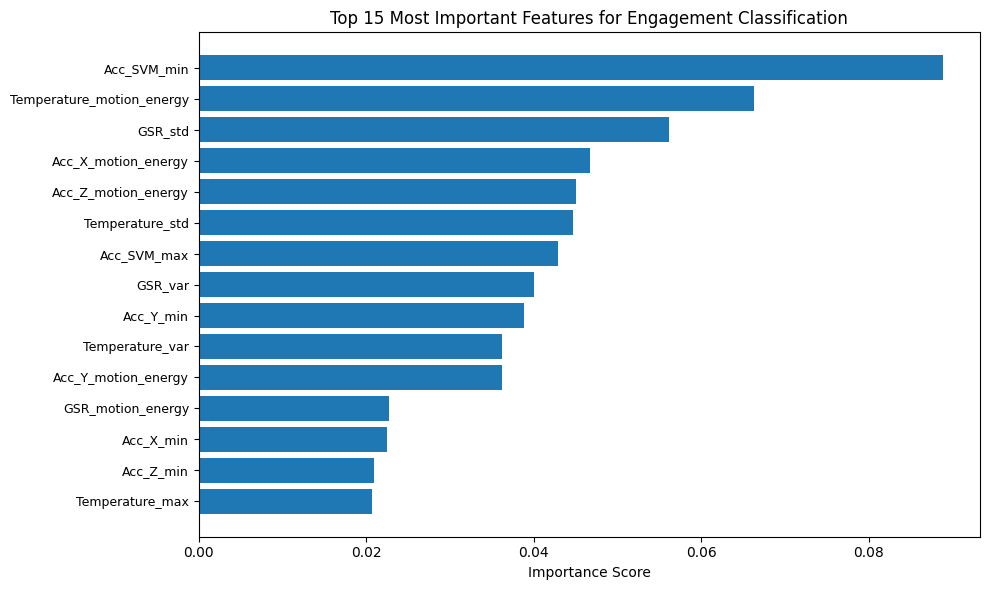


✓ Feature importance plot saved to ../results/feature_importance.png


In [30]:
# Feature Importance Analysis
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
for idx, row in feature_importance.head(20).iterrows():
    print(f"  {row['feature']:>30s}: {row['importance']:.4f}")

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values, fontsize=9)
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Most Important Features for Engagement Classification')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance plot saved to ../results/feature_importance.png")

In [31]:
# Save Model and Pipeline Information
print("\n" + "="*60)
print("SAVING MODEL & RESULTS")
print("="*60)

# Save the trained model
model_path = MODELS_PATH / "engagement_recognition_model.joblib"
joblib.dump(rf_model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save feature columns for future predictions
feature_cols_path = MODELS_PATH / "feature_columns.joblib"
joblib.dump(feature_cols, feature_cols_path)
print(f"✓ Feature columns saved to: {feature_cols_path}")

# Save model metrics
metrics_dict = {
    'test_accuracy': float(test_accuracy),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1),
    'train_accuracy': float(train_accuracy),
    'train_precision': float(train_precision),
    'train_recall': float(train_recall),
    'train_f1': float(train_f1),
    'confusion_matrix': cm.tolist(),
    'n_samples_train': int(len(X_train)),
    'n_samples_test': int(len(X_test)),
    'n_features': int(len(feature_cols))
}

metrics_path = RESULTS_PATH / "model_metrics.joblib"
joblib.dump(metrics_dict, metrics_path)
print(f"✓ Metrics saved to: {metrics_path}")

# Save feature importance
feature_importance.to_csv(RESULTS_PATH / "feature_importance.csv", index=False)
print(f"✓ Feature importance saved to: {RESULTS_PATH}/feature_importance.csv")

print("\n" + "="*60)
print("PIPELINE COMPLETE!")
print("="*60)


SAVING MODEL & RESULTS
✓ Model saved to: ../models/engagement_recognition_model.joblib
✓ Feature columns saved to: ../models/feature_columns.joblib
✓ Metrics saved to: ../results/model_metrics.joblib
✓ Feature importance saved to: ../results/feature_importance.csv

PIPELINE COMPLETE!


In [32]:
# Prediction Examples
print("\nPREDICTION EXAMPLES (First 10 Test Samples):\n")

label_map = {0: "Baseline", 1: "Low Engagement (LPE)", 2: "High Engagement (HPE)"}

for i in range(min(10, len(y_test))):
    true_label = label_map[y_test[i]]
    pred_label = label_map[y_test_pred[i]]
    confidence = np.max(rf_model.predict_proba([X_test[i]])) * 100
    match = "✓" if y_test[i] == y_test_pred[i] else "✗"
    
    print(f"{match} Sample {i+1:2d}: True={true_label:20s} | Pred={pred_label:20s} | Conf={confidence:5.1f}%")


# Summary Statistics
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\nDataset Statistics:")
print(f"  Total participants processed: {len(all_participant_data)}")
print(f"  Total samples generated: {len(final_dataset)}")
print(f"  Total features extracted: {len(feature_cols)}")
print(f"  Feature extraction window size: 60 seconds")
print(f"  Feature extraction step size: 30 seconds")

print(f"\nLabel Distribution:")
print(f"  Baseline (0):      {(y == 0).sum():4d} samples ({(y == 0).sum()/len(y)*100:5.1f}%)")
print(f"  Low Engagement (1): {(y == 1).sum():4d} samples ({(y == 1).sum()/len(y)*100:5.1f}%)")
print(f"  High Engagement (2):{(y == 2).sum():4d} samples ({(y == 2).sum()/len(y)*100:5.1f}%)")

print(f"\nModel Performance:")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print(f"  Test F1-Score: {test_f1:.4f}")

print(f"\nSaved Artifacts:")
print(f"  Model: {model_path}")
print(f"  Feature columns: {feature_cols_path}")
print(f"  Metrics: {metrics_path}")
print(f"  Feature importance: {RESULTS_PATH}/feature_importance.csv")
print(f"  Feature importance plot: {RESULTS_PATH}/feature_importance.png")


PREDICTION EXAMPLES (First 10 Test Samples):

✓ Sample  1: True=Low Engagement (LPE) | Pred=Low Engagement (LPE) | Conf= 46.4%
✓ Sample  2: True=Baseline             | Pred=Baseline             | Conf= 55.4%
✗ Sample  3: True=Low Engagement (LPE) | Pred=High Engagement (HPE) | Conf= 59.0%
✓ Sample  4: True=High Engagement (HPE) | Pred=High Engagement (HPE) | Conf= 73.1%
✓ Sample  5: True=High Engagement (HPE) | Pred=High Engagement (HPE) | Conf= 44.0%
✓ Sample  6: True=High Engagement (HPE) | Pred=High Engagement (HPE) | Conf= 55.7%
✓ Sample  7: True=Baseline             | Pred=Baseline             | Conf= 50.8%
✓ Sample  8: True=High Engagement (HPE) | Pred=High Engagement (HPE) | Conf= 82.0%
✓ Sample  9: True=High Engagement (HPE) | Pred=High Engagement (HPE) | Conf= 70.8%
✓ Sample 10: True=Low Engagement (LPE) | Pred=Low Engagement (LPE) | Conf= 51.3%

FINAL SUMMARY

Dataset Statistics:
  Total participants processed: 57
  Total samples generated: 464
  Total features extracted: 42

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_job

In [33]:
def predict_engagement(gsr_data, acc_data, tmp_data, model_path, feature_cols_path):
    """
    Make engagement predictions on new multimodal data.
    
    Parameters:
    -----------
    gsr_data : pd.DataFrame
        GSR data with UnixTime and GSR columns
    acc_data : pd.DataFrame
        Accelerometer data with UnixTime, Acc_X, Acc_Y, Acc_Z, Acc_SVM columns
    tmp_data : pd.DataFrame
        Temperature data with UnixTime and ST columns
    model_path : Path
        Path to saved model
    feature_cols_path : Path
        Path to saved feature columns
        
    Returns:
    --------
    dict : Dictionary with predictions and confidence scores
    """
    # Load model and feature columns
    model = joblib.load(model_path)
    feature_cols_loaded = joblib.load(feature_cols_path)
    
    # Merge signals
    merged = synchronize_and_merge_signals(gsr_data, acc_data, tmp_data)
    
    # Preprocess
    merged = handle_missing_values(merged, method='interpolate')
    merged_norm, _ = normalize_signals(merged)
    
    # Create windows and extract features
    windows = create_sliding_windows(merged_norm, window_size=60, step_size=30)
    features_list = extract_features_from_windows(windows)
    features_df = pd.DataFrame(features_list)
    
    # Ensure same features as training
    X_new = features_df[feature_cols_loaded].values
    
    # Make predictions
    predictions = model.predict(X_new)
    probabilities = model.predict_proba(X_new)
    
    label_map = {0: "Baseline", 1: "Low Engagement", 2: "High Engagement"}
    
    results = {
        'predictions': [label_map[p] for p in predictions],
        'prediction_codes': predictions.tolist(),
        'probabilities': probabilities.tolist(),
        'n_windows': len(predictions),
        'dominant_engagement': label_map[np.bincount(predictions).argmax()],
        'confidence': np.max(np.bincount(predictions)) / len(predictions)
    }
    
    return results


print("✓ Prediction function available: predict_engagement()")
print("\nTo use the model for new predictions:")
print("  results = predict_engagement(gsr_df, acc_df, tmp_df, model_path, feature_cols_path)")
print("  print(results['dominant_engagement'])")
print("  print(f\"Confidence: {results['confidence']:.2%}\")")

✓ Prediction function available: predict_engagement()

To use the model for new predictions:
  results = predict_engagement(gsr_df, acc_df, tmp_df, model_path, feature_cols_path)
  print(results['dominant_engagement'])
  print(f"Confidence: {results['confidence']:.2%}")
